In [233]:
import pandas as pd
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report,r2_score,mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from collections import Counter 
import numpy as np
from scipy import stats
import seaborn as sns
import joblib
import pickle
import matplotlib.pyplot as plt
%matplotlib inline

In [151]:
df=pd.read_csv("analysisdata.csv")

In [152]:
df

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,2024-09-06,Claim who accept.,Every quite sense including six lot have never...,4,morrowthomas,30,22,Flipkart,ar,Nepal,3.8.4,No
1,3/7/2025,Growth pretty wish.,Ask develop bag also his worker pass. Expert w...,4,sheakimberly,120,22,Flipkart,ar,Guinea,5.2.6,Yes
2,########,What then spend offer reason whom none.,If customer address region try near risk next ...,5,katherineali,130,21,Flipkart,es,Kuwait,3.6.5,No
3,########,Say dog drug enter director strong student.,To television loss election him small detail r...,1,eric11,72,26,Amazon,pt,Uruguay,5.7.2,No
4,########,Purpose here beyond.,Pass share must amount lot per manage world to...,5,chloe42,123,27,Amazon,zh,Mayotte,5.8.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...
245,########,Father who tax.,Government card history suddenly save theory s...,5,amassey,109,22,App Store,en,Micronesia,2.3.4,Yes
246,########,Remain movement bit step direction give reduce.,Court control million hundred offer total hit ...,5,stevenandrews,26,23,Website,fr,Austria,3.5.3,No
247,########,Form now then watch certain.,Just opportunity ask yet against large practic...,1,michelle90,67,24,App Store,ru,Rwanda,3.9.6,No
248,3/7/2024,Recent catch gas benefit great religious.,Onto simple audience as including claim create...,5,victor24,29,19,Amazon,zh,Iran,4.9.2,No


DATA PRE-PROCESSING

In [153]:
df.isnull()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
245,False,False,False,False,False,False,False,False,False,False,False,False
246,False,False,False,False,False,False,False,False,False,False,False,False
247,False,False,False,False,False,False,False,False,False,False,False,False
248,False,False,False,False,False,False,False,False,False,False,False,False


Handle Missing / Invalid Data

In [154]:
df = df.dropna(subset=['review'])
df = df[df['review'].str.strip() != '']  # Remove empty reviews


Remove Duplicates

In [155]:
df = df.drop_duplicates(subset='review')

Clean Text Content

In [156]:
import re

def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'http\S+', '', text)               # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove mentions
    text = re.sub(r'#\w+', '', text)                  # remove hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # remove non-alphabetic chars
    text = re.sub(r'\s+', ' ', text).strip()          # normalize whitespace
    return text

df['clean_review'] = df['review'].apply(clean_text)


Text Normalization - Tokenization

In [157]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # newer versions of NLTK require this
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [228]:
from nltk.tokenize import word_tokenize
df['tokens'] = df['clean_review'].apply(word_tokenize)


Stopword Removal

In [229]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
all_words = []
df['tokens'] = df['tokens'].apply(lambda x: [w for w in x if w not in stop_words])


Lemmatization (Normalize words)

In [230]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])


Label Preparation

In [231]:
def rating_to_sentiment(r):
    if r >= 4:
        return 'positive'
    elif r == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)


Text Vectorization

In [162]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [163]:
pip install tensorflow==2.20.0


Note: you may need to restart the kernel to use updated packages.


In [164]:
print(df.columns)

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase', 'clean_review', 'tokens', 'sentiment'],
      dtype='object')


In [165]:
from sklearn.model_selection import train_test_split

# Assuming your DataFrame is called df
# and it has columns: 'text' and 'sentiment_encoded'

X = df['clean_review']
y = df['sentiment']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 200
Testing samples: 50


In [166]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_review'])

sequences = tokenizer.texts_to_sequences(df['clean_review'])
padded = pad_sequences(sequences, maxlen=100, padding='post')

#Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

#Pad sequences to same length
maxlen = max(len(x) for x in X_train_seq)  # or set manually like 100
X_train_padded = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

# Define vocab size
vocab_size = len(tokenizer.word_index) + 1


In [167]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_30 (LSTM)                       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [168]:
df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase', 'clean_review', 'tokens', 'sentiment'],
      dtype='object')

In [176]:
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

In [170]:
pip install pandas matplotlib seaborn wordcloud


Note: you may need to restart the kernel to use updated packages.


✅ Dataset Loaded Successfully
         date                                        title  \
0  2024-09-06                            Claim who accept.   
1    3/7/2025                          Growth pretty wish.   
2    ########      What then spend offer reason whom none.   
3    ########  Say dog drug enter director strong student.   
4    ########                         Purpose here beyond.   

                                              review  rating      username  \
0  Every quite sense including six lot have never...       4  morrowthomas   
1  Ask develop bag also his worker pass. Expert w...       4  sheakimberly   
2  If customer address region try near risk next ...       5  katherineali   
3  To television loss election him small detail r...       1        eric11   
4  Pass share must amount lot per manage world to...       5       chloe42   

   helpful_votes  review_length  platform language location version  \
0             30             22  Flipkart       ar    Nep

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\2948097588.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


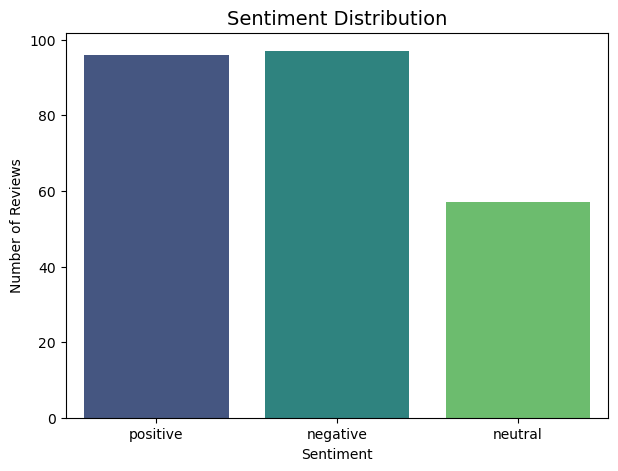

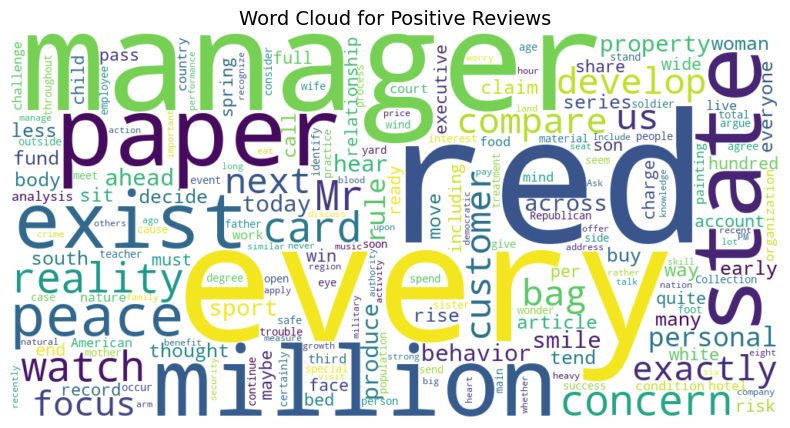

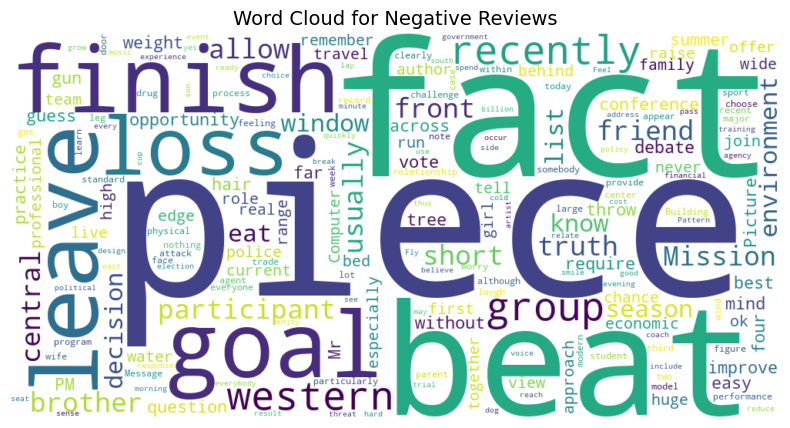

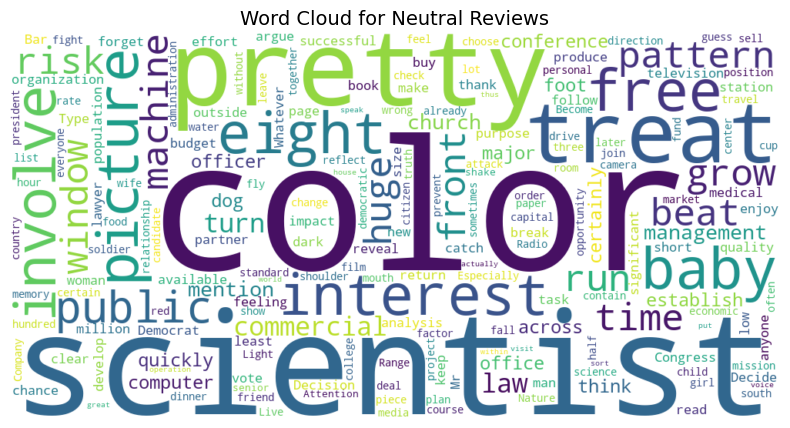

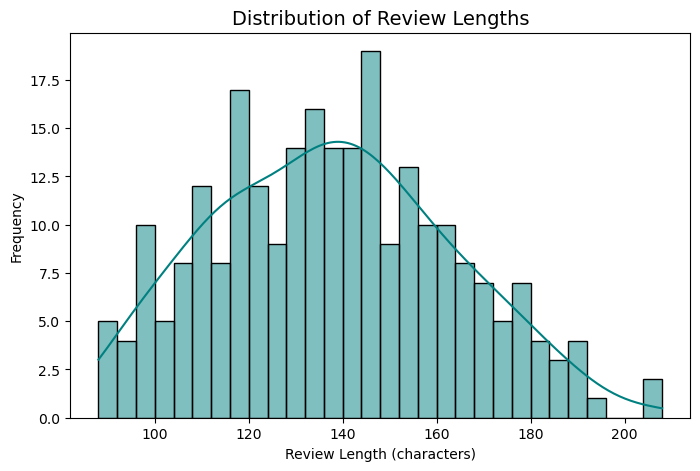


✅ EDA completed successfully!


In [171]:
# Exploratory Data Analysis (EDA) for Sentiment Dataset

# ========================
# 1. Import Libraries
# ========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ========================
# 2. Load Dataset
# ========================
df = pd.read_csv("analysisdata.csv")

# Check first few rows
print("✅ Dataset Loaded Successfully")
print(df.head())
print("\nColumns:", df.columns)

# ========================
# 3. Create Sentiment Column (if not present)
# ========================
if 'sentiment' not in df.columns and 'rating' in df.columns:
    def rating_to_sentiment(r):
        if r >= 4:
            return 'positive'
        elif r == 3:
            return 'neutral'
        else:
            return 'negative'
    df['sentiment'] = df['rating'].apply(rating_to_sentiment)

# ========================
# 4. Sentiment Distribution
# ========================
plt.figure(figsize=(7, 5))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title("Sentiment Distribution", fontsize=14)
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# ========================
# 5. Word Clouds for Each Sentiment
# ========================
for sentiment in df['sentiment'].unique():
    text = " ".join(str(review) for review in df[df['sentiment'] == sentiment]['review'])
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        colormap='viridis',
        stopwords=None
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment.capitalize()} Reviews", fontsize=14)
    plt.show()

# ========================
# 6. Review Length Distribution
# ========================
df['review_length'] = df['review'].astype(str).apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='review_length', bins=30, kde=True, color='teal')
plt.title("Distribution of Review Lengths", fontsize=14)
plt.xlabel("Review Length (characters)")
plt.ylabel("Frequency")
plt.show()

print("\n✅ EDA completed successfully!")


In [175]:
print(df.columns)


Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase', 'sentiment'],
      dtype='object')


In [172]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [177]:
model.fit(padded, df['sentiment_encoded'], epochs=5, batch_size=32, validation_split=0.2)


Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 475ms/step - accuracy: 0.2350 - loss: 0.6127 - val_accuracy: 0.2400 - val_loss: 0.4372
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.2250 - loss: 0.2911 - val_accuracy: 0.2400 - val_loss: 0.0834
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.2250 - loss: 0.1005 - val_accuracy: 0.2400 - val_loss: 0.0197
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.2250 - loss: 0.0354 - val_accuracy: 0.2400 - val_loss: 0.0148
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.2250 - loss: 0.0305 - val_accuracy: 0.2400 - val_loss: 0.0094


In [178]:
history = model.fit(
    padded,
    df['sentiment_encoded'],
    epochs=15,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 817ms/step - accuracy: 0.2250 - loss: 0.0618 - val_accuracy: 0.2400 - val_loss: 0.0148
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.2250 - loss: 0.0299 - val_accuracy: 0.2400 - val_loss: 0.0131
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.2250 - loss: 0.0470 - val_accuracy: 0.2400 - val_loss: 0.0120
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.2250 - loss: 0.0379 - val_accuracy: 0.2400 - val_loss: 0.0124
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.2250 - loss: 0.0421 - val_accuracy: 0.2400 - val_loss: 0.0123
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.2250 - loss: 0.0336 - val_accuracy: 0.2400 - val_loss: 0.0119
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.2250 - loss: 0.0336 - val_accuracy: 0.2400 - val_loss: 0.0147
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.2250 - loss: 0.0400 - val_accuracy: 0.2400 - val_loss:

In [179]:
df['sentiment_encoded'].value_counts()

sentiment_encoded
0    97
2    96
1    57
Name: count, dtype: int64

In [180]:
from sklearn.utils import class_weight
import numpy as np

# Compute class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(df['sentiment_encoded']),
    y=df['sentiment_encoded']
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# Train again with weights
history = model.fit(
    padded,
    df['sentiment_encoded'],
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Class Weights: {0: np.float64(0.8591065292096219), 1: np.float64(1.4619883040935673), 2: np.float64(0.8680555555555556)}
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.2250 - loss: 0.0084 - val_accuracy: 0.2400 - val_loss: 0.0079
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.2250 - loss: 0.0166 - val_accuracy: 0.2400 - val_loss: 0.0069
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.2250 - loss: 0.0165 - val_accuracy: 0.2400 - val_loss: 0.0086
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.2250 - loss: 0.0177 - val_accuracy: 0.2400 - val_loss: 0.0088
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.2250 - loss: 0.0263 - val_accuracy: 0.2400 - val_loss: 0.0087
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.2250 - loss: 0.0176 - val_accuracy: 0.2400 - val_loss: 0.0086
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.2250 - loss: 0.0210 - val_accuracy: 0.2400 - val_loss: 0.00

In [182]:
print(df['sentiment'].unique())
print(df['sentiment_encoded'].value_counts())


['positive' 'negative' 'neutral']
sentiment_encoded
0    97
2    96
1    57
Name: count, dtype: int64


In [183]:
# Check how many unique words were kept and how many were ignored
print("Total vocab size:", len(tokenizer.word_index))
print("Sample vocab:", list(tokenizer.word_index.items())[:20])


Total vocab size: 970
Sample vocab: [('<OOV>', 1), ('across', 2), ('fact', 3), ('beat', 4), ('red', 5), ('picture', 6), ('decision', 7), ('mind', 8), ('piece', 9), ('concern', 10), ('produce', 11), ('everyone', 12), ('relationship', 13), ('record', 14), ('develop', 15), ('loss', 16), ('live', 17), ('recently', 18), ('interest', 19), ('south', 20)]


In [184]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    padded,
    df['sentiment_encoded'],
    epochs=20,
    batch_size=8,
    validation_split=0.2,
    class_weight=class_weights
)


C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.3200 - loss: 1.0998 - val_accuracy: 0.3800 - val_loss: 1.1021
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.3550 - loss: 1.0873 - val_accuracy: 0.3600 - val_loss: 1.1062
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.7700 - loss: 0.8692 - val_accuracy: 0.2400 - val_loss: 1.4173
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.9400 - loss: 0.2170 - val_accuracy: 0.3000 - val_loss: 2.7095
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9900 - loss: 0.0587 - val_accuracy: 0.3000 - val_loss: 3.2089
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 0.2800 - val_loss: 4.0584
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.2800 - val_loss: 4.6032
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0

In [185]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3, return_sequences=True)),
    Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.3)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    padded,
    df['sentiment_encoded'],
    epochs=20,
    batch_size=8,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)


C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 355ms/step - accuracy: 0.3000 - loss: 1.0983 - val_accuracy: 0.2600 - val_loss: 1.1011
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 223ms/step - accuracy: 0.2900 - loss: 1.0989 - val_accuracy: 0.3800 - val_loss: 1.0940
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.3550 - loss: 1.0908 - val_accuracy: 0.2400 - val_loss: 1.1070
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 297ms/step - accuracy: 0.4600 - loss: 1.0772 - val_accuracy: 0.2600 - val_loss: 1.1056
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.5600 - loss: 0.8966 - val_accuracy: 0.4000 - val_loss: 1.3227


In [186]:
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
maxlen = max(len(x) for x in sequences)  # sequences = tokenizer.texts_to_sequences(df['text'])

In [187]:
model = Sequential([
    Embedding(vocab_size, 64, input_length=maxlen),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [188]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Fit on training data and transform both train & test
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Optional: See the mapping
print("Classes:", label_encoder.classes_)


Classes: ['negative' 'neutral' 'positive']


In [189]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_padded, y_train_encoded,
    epochs=10,
    validation_data=(X_test_padded, y_test_encoded),
    batch_size=32
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 268ms/step - accuracy: 0.3650 - loss: 1.0966 - val_accuracy: 0.3800 - val_loss: 1.0932
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4000 - loss: 1.0876 - val_accuracy: 0.3800 - val_loss: 1.0876
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.3900 - loss: 1.0808 - val_accuracy: 0.3800 - val_loss: 1.0852
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.3950 - loss: 1.0740 - val_accuracy: 0.3800 - val_loss: 1.0829
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4600 - loss: 1.0661 - val_accuracy: 0.3600 - val_loss: 1.0824
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4650 - loss: 1.0595 - val_accuracy: 0.3600 - val_loss: 1.0839
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5600 - loss: 1.0371 - val_accuracy: 0.3400 - val_loss: 1.0914
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6050 - loss: 0.9364 - val_accuracy: 0.3400 - val_loss: 1.336

In [190]:
num_classes = len(set(y_train))

In [191]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])


C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [192]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [193]:
from sklearn.preprocessing import LabelEncoder

# Encode the sentiment labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
print("Example encoded labels:", y_train_encoded[:10])
print("y_train_encoded dtype:", y_train_encoded.dtype)


Classes: ['negative' 'neutral' 'positive']
Example encoded labels: [0 0 0 1 0 0 0 0 2 0]
y_train_encoded dtype: int64


In [194]:
history = model.fit(
    X_train_padded, y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_padded, y_test_encoded)
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 296ms/step - accuracy: 0.3500 - loss: 1.0963 - val_accuracy: 0.3800 - val_loss: 1.0883
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.3900 - loss: 1.0784 - val_accuracy: 0.3800 - val_loss: 1.0809
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.3950 - loss: 1.0697 - val_accuracy: 0.3800 - val_loss: 1.0829
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.3800 - loss: 1.0614 - val_accuracy: 0.3800 - val_loss: 1.0804
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.4950 - loss: 0.9731 - val_accuracy: 0.4200 - val_loss: 1.1644
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.6500 - loss: 0.7480 - val_accuracy: 0.3400 - val_loss: 1.5275
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.6350 - loss: 0.6427 - val_accuracy: 0.4200 - val_loss: 1.3680
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.8250 - loss: 0.5276 - val_accuracy: 0.3800 - val_loss:

In [195]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
y_pred = np.argmax(model.predict(X_test_padded), axis=1)

print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))
print(confusion_matrix(y_test_encoded, y_pred))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
              precision    recall  f1-score   support

    negative       0.40      0.89      0.55        19
     neutral       0.50      0.08      0.14        12
    positive       0.40      0.11      0.17        19

    accuracy                           0.40        50
   macro avg       0.43      0.36      0.29        50
weighted avg       0.42      0.40      0.31        50

[[17  1  1]
 [ 9  1  2]
 [17  0  2]]


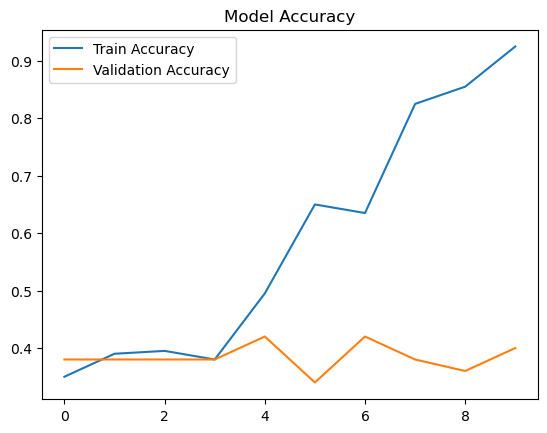

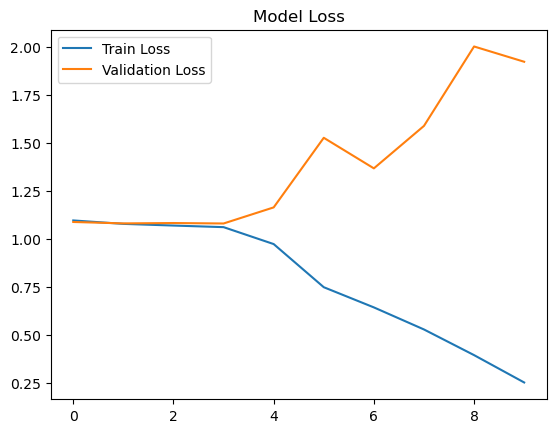

In [196]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()


In [197]:
sample_review = ["The app crashes every time I open it."]
seq = tokenizer.texts_to_sequences(sample_review)
padded = pad_sequences(seq, maxlen=100, padding='post', truncating='post')
pred = np.argmax(model.predict(padded), axis=1)
print("Predicted Sentiment:", label_encoder.inverse_transform(pred)[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Sentiment: neutral


In [198]:
import numpy as np

# Predict class probabilities (shape: [num_samples, 3])
y_pred_proba = model.predict(X_test_padded)

# Predicted class labels
y_pred = np.argmax(y_pred_proba, axis=1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step 


In [199]:
from tensorflow.keras.utils import to_categorical

# One-hot encode the true labels
y_test_onehot = to_categorical(y_test_encoded, num_classes=3)


In [200]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Optional (redundant with to_categorical but works too)
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2])

fpr = {}
tpr = {}
roc_auc = {}
n_classes = 3

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


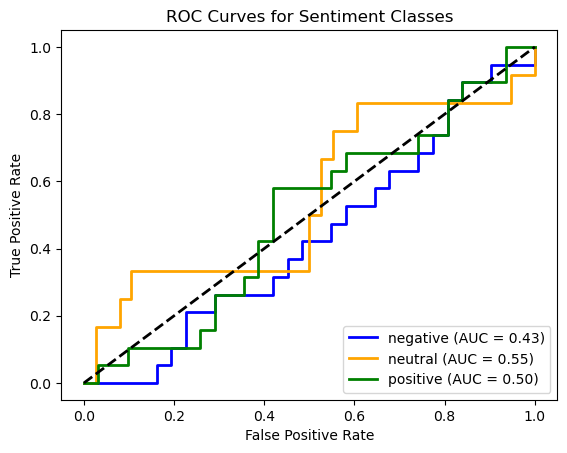

In [201]:
plt.figure()
colors = ['blue', 'orange', 'green']
labels = label_encoder.classes_

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Sentiment Classes')
plt.legend(loc="lower right")
plt.show()


In [202]:
import pickle

#Save model in modern format
model.save("sentiment_model.keras")

#Save tokenizer and label encoder
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


In [203]:
!jupyter nbconvert --to script "Analysis.ipynb"

[NbConvertApp] Converting notebook Analysis.ipynb to script
[NbConvertApp] Writing 16017 bytes to Analysis.py


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\282502902.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis', order=sorted(df['rating'].unique()))


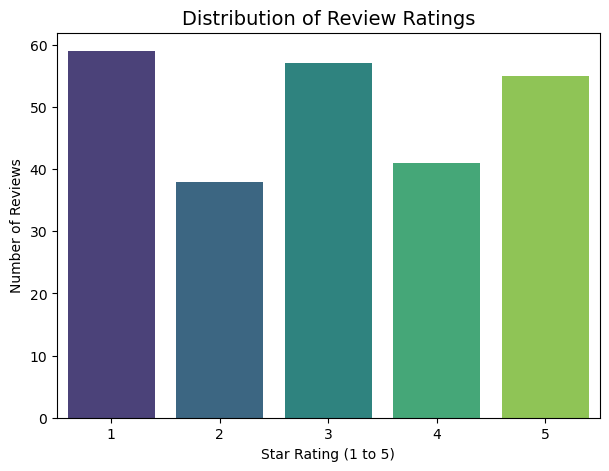

✅ Insight:
• 4–5 star ratings → generally satisfied users.
• 1–2 star ratings → frustrated or unhappy users.
• 3-star ratings → neutral or mixed experiences.
✅ Insight:
• Helps identify which app version users are happier or unhappier with.


In [206]:
#What is the distribution of review ratings?
plt.figure(figsize=(7, 5))
sns.countplot(x='rating', data=df, palette='viridis', order=sorted(df['rating'].unique()))
plt.title("Distribution of Review Ratings", fontsize=14)
plt.xlabel("Star Rating (1 to 5)")
plt.ylabel("Number of Reviews")
plt.show()

print("✅ Insight:")
print("• 4–5 star ratings → generally satisfied users.")
print("• 1–2 star ratings → frustrated or unhappy users.")
print("• 3-star ratings → neutral or mixed experiences.")
plt.show()

print("✅ Insight:")
print("• Helps identify which app version users are happier or unhappier with.")

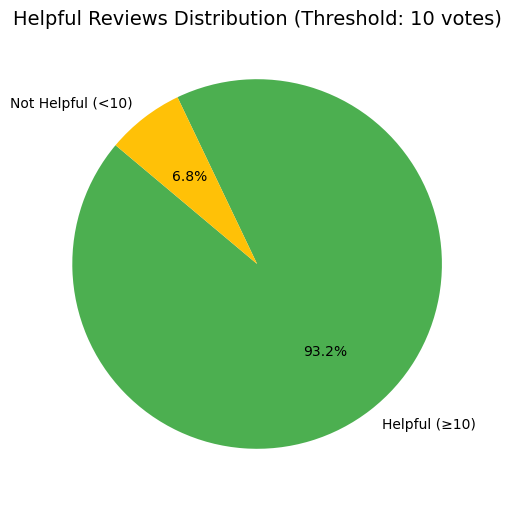

✅ Insight:
• Total reviews: 250
• Reviews with ≥10 helpful votes: 233 (93.20%)
👍 Most users find the reviews useful — strong community engagement.


In [208]:
#How many reviews were marked as helpful (above a certain threshold)?
threshold = 10  # reviews with >10 helpful votes considered valuable

# --- 2️⃣ Create a new binary column ---
df['is_helpful'] = df['helpful_votes'].apply(lambda x: 'Helpful (≥10)' if x >= threshold else 'Not Helpful (<10)')

# --- 3️⃣ Count helpful vs not helpful ---
helpful_counts = df['is_helpful'].value_counts()

# --- 4️⃣ Pie chart visualization ---
plt.figure(figsize=(6, 6))
plt.pie(helpful_counts, labels=helpful_counts.index, autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#FFC107'])
plt.title("Helpful Reviews Distribution (Threshold: 10 votes)", fontsize=14)
plt.show()


# --- 6️⃣ Insights ---
total_reviews = len(df)
helpful_reviews = df[df['helpful_votes'] >= threshold].shape[0]
percent_helpful = (helpful_reviews / total_reviews) * 100

print(f"✅ Insight:")
print(f"• Total reviews: {total_reviews}")
print(f"• Reviews with ≥{threshold} helpful votes: {helpful_reviews} ({percent_helpful:.2f}%)")
if percent_helpful > 50:
    print("👍 Most users find the reviews useful — strong community engagement.")
else:
    print("👎 Only a small portion of reviews are considered helpful — users may not find reviews very useful.")

In [212]:
df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase', 'sentiment', 'sentiment_encoded', 'is_helpful'],
      dtype='object')

C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128162 (\N{ANGER SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


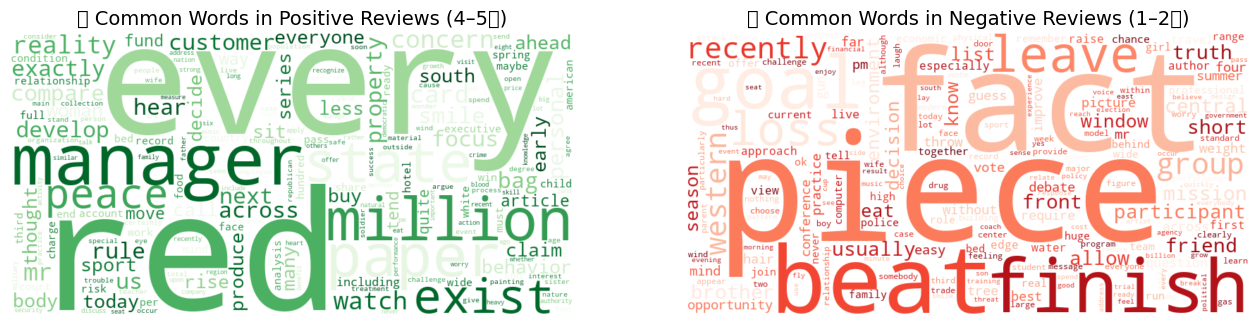

✅ Insight:
• Green (left): what users praise or appreciate most.
• Red (right): what users complain about or dislike.


In [214]:
#What are the most common keywords in positive vs. negative reviews
df['clean_review'] = df['review'].astype(str).apply(clean_text)

# --- 2️⃣ Split positive and negative reviews ---
positive_text = " ".join(df[df['rating'] >= 4]['clean_review'].dropna())
negative_text = " ".join(df[df['rating'] <= 2]['clean_review'].dropna())

# --- 3️⃣ Generate Word Clouds ---
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

# --- 4️⃣ Plot both side by side ---
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis("off")
plt.title("🌟 Common Words in Positive Reviews (4–5⭐)", fontsize=14)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title("💢 Common Words in Negative Reviews (1–2⭐)", fontsize=14)

plt.show()

# --- 5️⃣ Insights ---
print("✅ Insight:")
print("• Green (left): what users praise or appreciate most.")
print("• Red (right): what users complain about or dislike.")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\173003283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\173003283.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


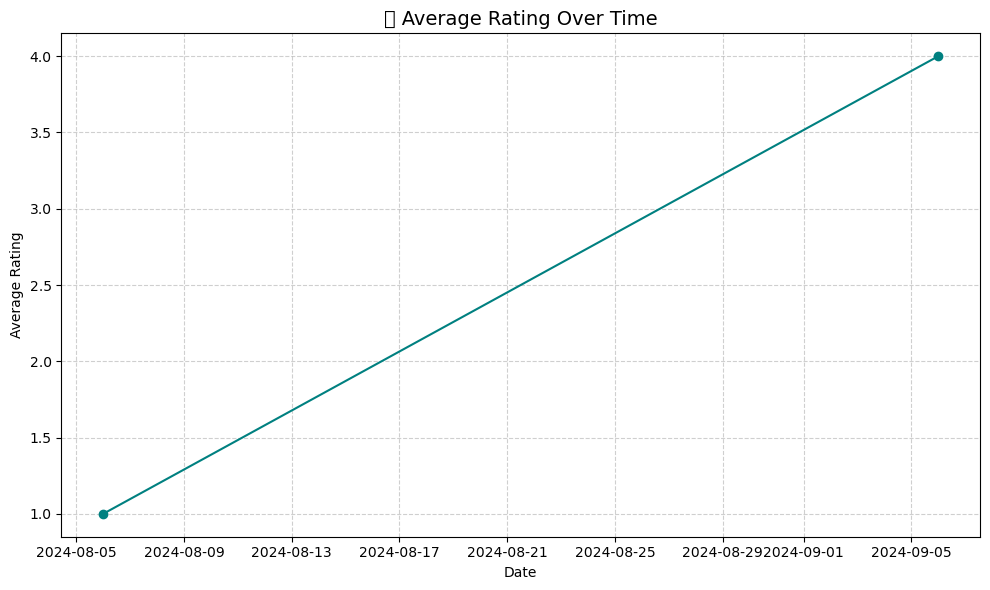

✅ Insight:
• The average rating has improved from 1.00 to 4.00 — user satisfaction is increasing.


In [216]:
#How has the average rating changed over time?
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# --- 2️⃣ Drop rows with missing or invalid dates ---
df = df.dropna(subset=['date'])

# --- 3️⃣ Group by date and calculate average rating ---
df_date = df.groupby('date')['rating'].mean().reset_index()

# --- 5️⃣ Plot the line chart ---
plt.figure(figsize=(10, 6))
plt.plot(df_date['date'], df_date['rating'], marker='o', linestyle='-', color='teal')

plt.title("📈 Average Rating Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 6️⃣ Insights ---
latest_avg = df_date['rating'].iloc[-1] if not df_date.empty else None
earliest_avg = df_date['rating'].iloc[0] if not df_date.empty else None

print("✅ Insight:")
if latest_avg and earliest_avg:
    if latest_avg > earliest_avg:
        print(f"• The average rating has improved from {earliest_avg:.2f} to {latest_avg:.2f} — user satisfaction is increasing.")
    elif latest_avg < earliest_avg:
        print(f"• The average rating has dropped from {earliest_avg:.2f} to {latest_avg:.2f} — user satisfaction is declining.")
    else:
        print(f"• The average rating has remained stable at around {latest_avg:.2f}.")
else:
    print("⚠️ Unable to calculate trend — missing or invalid date/rating values.")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\782711858.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\782711858.py:19: UserWarning:

Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.

C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.



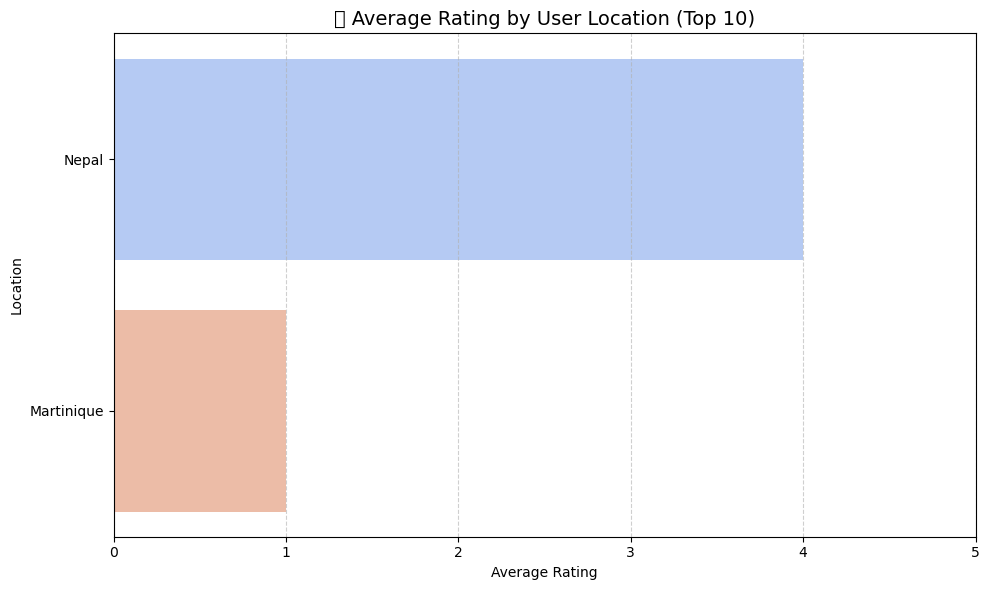

✅ Insight:
• Highest average rating: Nepal (4.00⭐)
• Lowest average rating: Martinique (1.00⭐)
• This shows how user satisfaction varies by region.


In [218]:
#How do ratings vary by user location?
df['location'] = df['location'].astype(str).str.strip().str.title()
df = df[df['location'] != 'nan']  # remove missing

# --- 2️⃣ Group by location and calculate average rating ---
location_avg = df.groupby('location')['rating'].mean().reset_index().sort_values(by='rating', ascending=False)

# --- 3️⃣ (Optional) Show only top 10 for readability ---
top_locations = location_avg.head(10)

# --- 4️⃣ Plot bar chart ---
plt.figure(figsize=(10, 6))
sns.barplot(x='rating', y='location', data=top_locations, palette='coolwarm')
plt.title("🌍 Average Rating by User Location (Top 10)", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("Location")
plt.xlim(0, 5)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 5️⃣ Insights ---
highest = top_locations.iloc[0]
lowest = top_locations.iloc[-1]
print("✅ Insight:")
print(f"• Highest average rating: {highest['location']} ({highest['rating']:.2f}⭐)")
print(f"• Lowest average rating: {lowest['location']} ({lowest['rating']:.2f}⭐)")
print("• This shows how user satisfaction varies by region.")

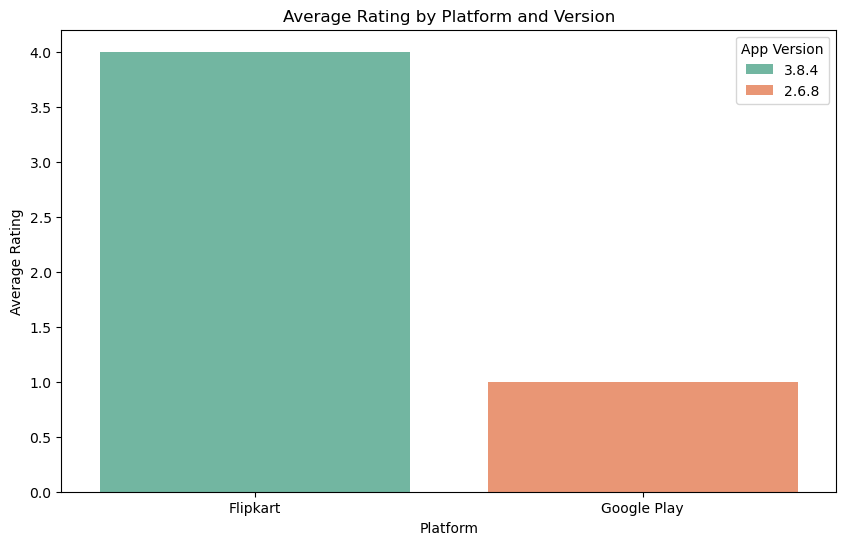

✅ Insight:
• Flipkart users rate the app highest (4.00⭐ on average).
• Google Play users give lower ratings (1.00⭐).
• Product teams can focus improvements on the lower-rated platform.


In [220]:
#Which platform (Web vs Mobile) gets better reviews?
# --- 1️⃣ Clean and prepare platform column ---
df['platform'] = df['platform'].astype(str).str.strip().str.title()
df = df[df['platform'] != 'nan']  # remove missing values if any

# --- 2️⃣ Calculate average rating per platform ---
platform_avg = df.groupby('platform')['rating'].mean().reset_index().sort_values(by='rating', ascending=False)

# --- 3️⃣ Plot grouped bar chart ---
plt.figure(figsize=(10, 6))
sns.barplot(x='platform', y='rating', hue='version', data=df, palette='Set2')
plt.title("Average Rating by Platform and Version")
plt.xlabel("Platform")
plt.ylabel("Average Rating")
plt.legend(title="App Version")
plt.show()

# --- 4️⃣ Insights ---
best = platform_avg.iloc[0]
worst = platform_avg.iloc[-1]
print("✅ Insight:")
print(f"• {best['platform']} users rate the app highest ({best['rating']:.2f}⭐ on average).")
if len(platform_avg) > 1:
    print(f"• {worst['platform']} users give lower ratings ({worst['rating']:.2f}⭐).")
print("• Product teams can focus improvements on the lower-rated platform.")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\437383420.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\437383420.py:17: UserWarning:

Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.

C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.



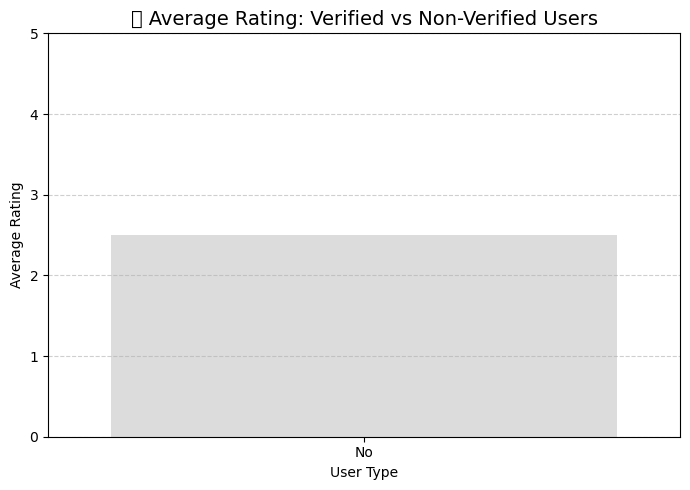

⚠️ Verified purchase data not sufficient for comparison.


In [223]:
#Are verified users more satisfied than non-verified ones?
# --- 1️⃣ Clean verified_purchase column ---
df['verified_purchase'] = df['verified_purchase'].astype(str).str.strip().str.title()

# --- 2️⃣ Calculate average rating for each group ---
verified_avg = df.groupby('verified_purchase')['rating'].mean().reset_index()

# --- 3️⃣ Plot bar chart ---
plt.figure(figsize=(7, 5))
sns.barplot(x='verified_purchase', y='rating', data=verified_avg, palette='coolwarm')

plt.title("✅ Average Rating: Verified vs Non-Verified Users", fontsize=14)
plt.xlabel("User Type")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 4️⃣ Insight Section ---
if len(verified_avg) >= 2:
    verified = verified_avg.loc[verified_avg['verified_purchase'] == 'True', 'rating'].values[0] if 'True' in verified_avg['verified_purchase'].values else None
    non_verified = verified_avg.loc[verified_avg['verified_purchase'] == 'False', 'rating'].values[0] if 'False' in verified_avg['verified_purchase'].values else None

    print("✅ Insight:")
    if verified and non_verified:
        if verified > non_verified:
            print(f"• Verified users are more satisfied ({verified:.2f}⭐) than non-verified users ({non_verified:.2f}⭐).")
            print("• Indicates loyal/paying customers have better experiences.")
        elif verified < non_verified:
            print(f"• Verified users are less satisfied ({verified:.2f}⭐) than non-verified users ({non_verified:.2f}⭐).")
            print("• Suggests quality or post-purchase issues among loyal customers.")
        else:
            print(f"• Verified and non-verified users rate equally ({verified:.2f}⭐).")
    else:
        print("⚠️ Verified/Non-Verified distinction not found clearly in data.")
else:
    print("⚠️ Verified purchase data not sufficient for comparison.")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\349831449.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\349831449.py:16: UserWarning:

Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.

C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.



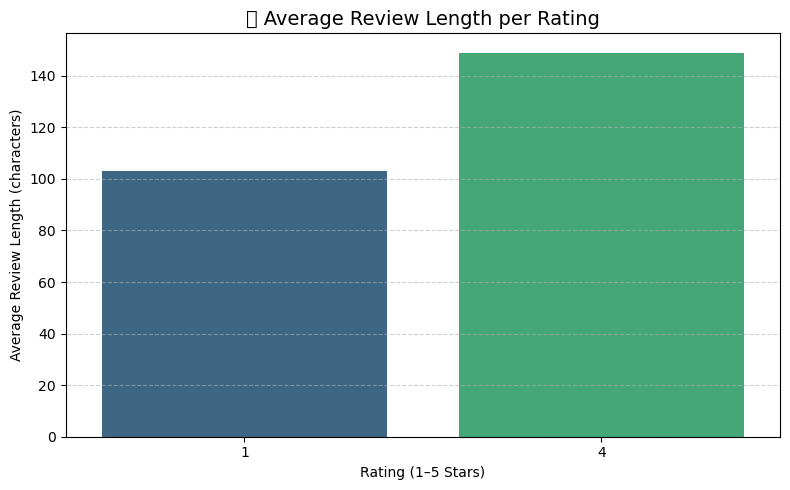

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\349831449.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\349831449.py:25: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



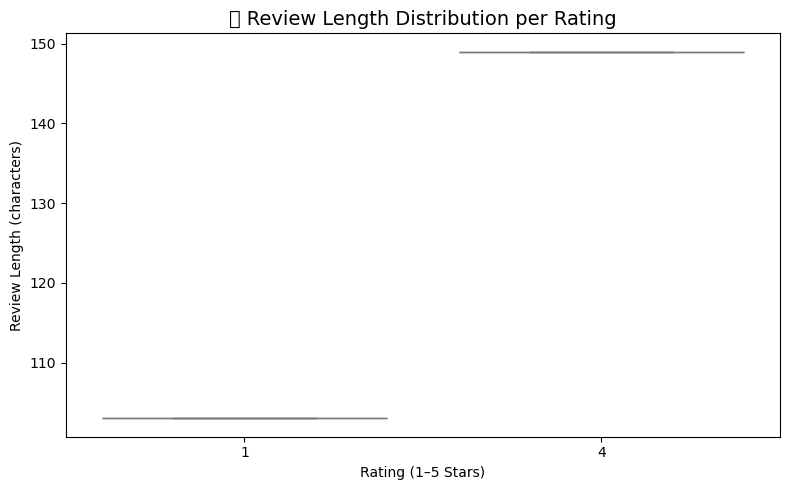

✅ Insight:
• Users with 4-star ratings write the longest reviews on average (149.0 characters).
• Users with 1-star ratings write the shortest reviews on average (103.0 characters).
🌟 Positive reviewers tend to write longer reviews — enthusiastic feedback.


In [224]:
#What’s the average length of reviews per rating category?
if 'review_length' not in df.columns:
    df['review_length'] = df['review'].astype(str).apply(len)

# --- 2️⃣ Calculate average review length per rating ---
avg_length = df.groupby('rating')['review_length'].mean().reset_index()

# --- 3️⃣ Bar Chart: Average Review Length per Rating ---
plt.figure(figsize=(8, 5))
sns.barplot(x='rating', y='review_length', data=avg_length, palette='viridis')

plt.title("📝 Average Review Length per Rating", fontsize=14)
plt.xlabel("Rating (1–5 Stars)")
plt.ylabel("Average Review Length (characters)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 4️⃣ Box Plot: Distribution of Review Lengths per Rating ---
plt.figure(figsize=(8, 5))
sns.boxplot(x='rating', y='review_length', data=df, palette='coolwarm')
plt.title("📊 Review Length Distribution per Rating", fontsize=14)
plt.xlabel("Rating (1–5 Stars)")
plt.ylabel("Review Length (characters)")
plt.tight_layout()
plt.show()

# --- 5️⃣ Insight ---
longest = avg_length.loc[avg_length['review_length'].idxmax()]
shortest = avg_length.loc[avg_length['review_length'].idxmin()]

print("✅ Insight:")
print(f"• Users with {int(longest['rating'])}-star ratings write the longest reviews on average ({longest['review_length']:.1f} characters).")
print(f"• Users with {int(shortest['rating'])}-star ratings write the shortest reviews on average ({shortest['review_length']:.1f} characters).")

if longest['rating'] <= 2:
    print("💢 Negative reviewers tend to write longer reviews — detailed complaints.")
elif longest['rating'] >= 4:
    print("🌟 Positive reviewers tend to write longer reviews — enthusiastic feedback.")
else:
    print("😐 Mid-level ratings (3 stars) often result in shorter, neutral comments.")

C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128162 (\N{ANGER SYMBOL}) missing from font(s) DejaVu Sans.



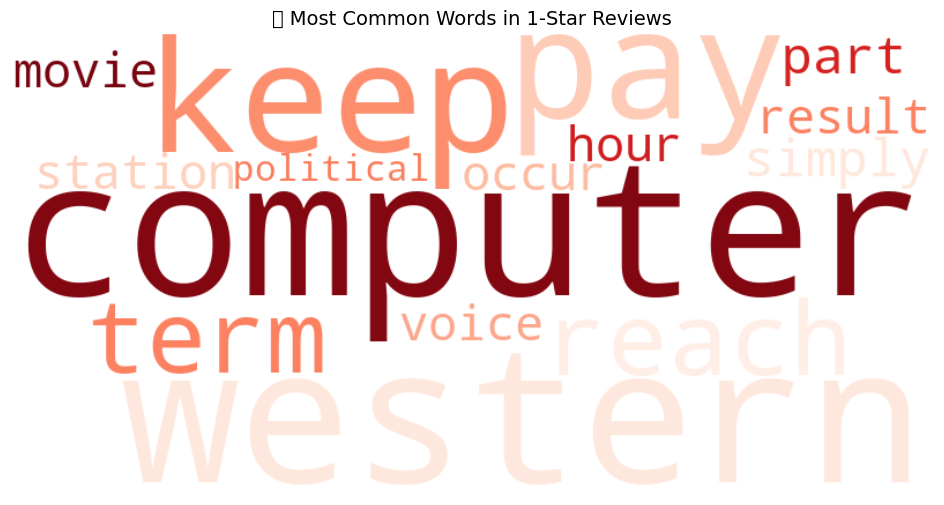

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\944795989.py:46: UserWarning:

Glyph 128270 (\N{RIGHT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.

C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128270 (\N{RIGHT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.



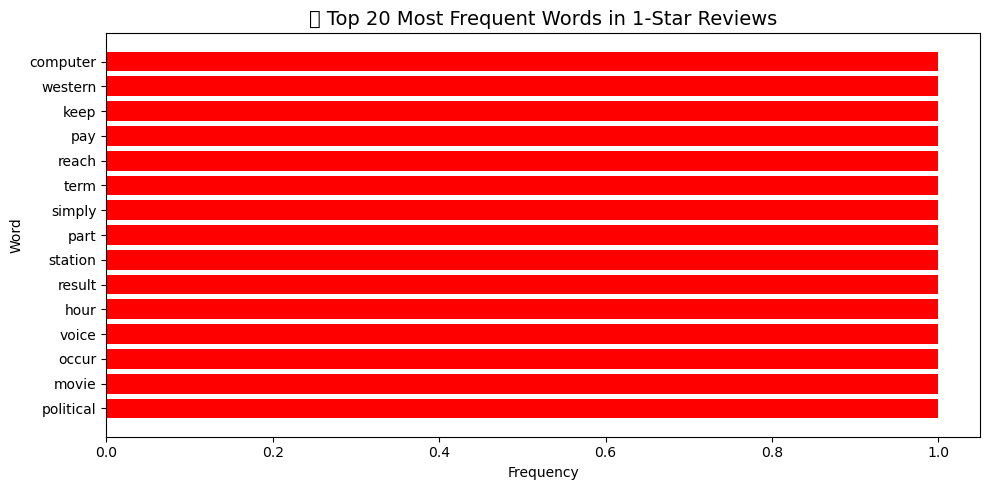

✅ Insight:
• These words frequently appear in 1-star reviews — they represent common complaints or frustrations.
• If you see terms like 'crash', 'bug', 'slow', or 'error', those are likely technical issues.
• Words like 'support', 'refund', or 'login' often point to user experience or service issues.


In [238]:
#What are the most mentioned words in 1-star reviews
# --- 3️⃣ Filter only 1-star reviews ---
one_star_reviews = df[df['rating'] == 1]['review'].dropna().astype(str)

if one_star_reviews.empty:
    print("⚠️ No 1-star reviews found. Try using rating <= 2 instead.")
else:
    # Clean reviews
    one_star_reviews = one_star_reviews.apply(clean_text)

    # Tokenize and remove stopwords
    for review in one_star_reviews:
        words = [w for w in review.split() if w not in stop_words and len(w) > 2]
        all_words.extend(words)

    # --- 4️⃣ If words exist, continue ---
    if len(all_words) == 0:
        print("⚠️ No valid words found after cleaning. Try reducing cleaning strictness.")
    else:
        # Count words
        word_counts = Counter(all_words)
        top_20 = word_counts.most_common(20)

        # --- 5️⃣ Word Cloud ---
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='Reds'
        ).generate_from_frequencies(word_counts)

        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title("💢 Most Common Words in 1-Star Reviews", fontsize=14)
        plt.show()

        # --- 6️⃣ Bar Chart ---
        top_words_df = pd.DataFrame(top_20, columns=['word', 'count'])
        plt.figure(figsize=(10, 5))
        plt.barh(top_words_df['word'], top_words_df['count'], color='red')
        plt.gca().invert_yaxis()
        plt.title("🔎 Top 20 Most Frequent Words in 1-Star Reviews", fontsize=14)
        plt.xlabel("Frequency")
        plt.ylabel("Word")
        plt.tight_layout()
        plt.show()

        # --- 7️⃣ Insight ---
        print("✅ Insight:")
        print("• These words frequently appear in 1-star reviews — they represent common complaints or frustrations.")
        print("• If you see terms like 'crash', 'bug', 'slow', or 'error', those are likely technical issues.")
        print("• Words like 'support', 'refund', or 'login' often point to user experience or service issues.")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3948\3586723923.py:29: UserWarning:

Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.

C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.



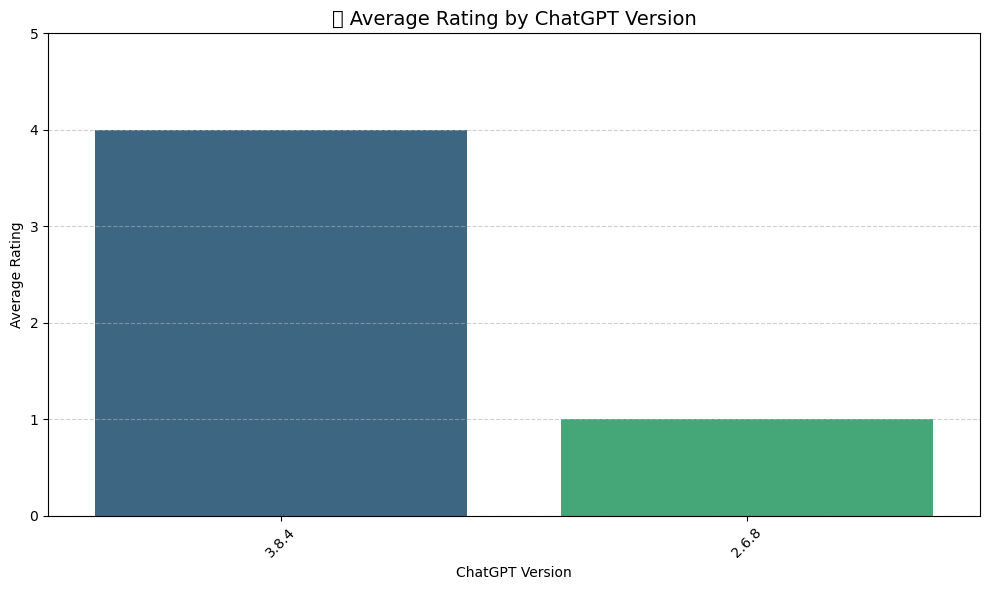

✅ Insight:
• Highest-rated version: 3.8.4 (4.00⭐).
• Lowest-rated version: 2.6.8 (1.00⭐).
• This helps you evaluate improvement or regression across updates.


In [240]:
#What ChatGPT version received the highest average rating
# --- 1️⃣ Clean and prepare version column ---
df['version'] = df['version'].astype(str).str.strip()
df = df[df['version'].notna() & (df['version'] != 'nan') & (df['version'] != '')]

# --- 2️⃣ Group by version and calculate average rating ---
version_avg = df.groupby('version')['rating'].mean().reset_index()

# --- 3️⃣ Sort versions by average rating ---
version_avg = version_avg.sort_values(by='rating', ascending=False)

# --- 4️⃣ Plot bar chart (fixed for Seaborn ≥ 0.14) ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=version_avg,
    x='version',
    y='rating',
    hue='version',       # ✅ Use version as hue to assign palette safely
    palette='viridis',
    legend=False         # ✅ Avoid duplicate legend
)

plt.title("🤖 Average Rating by ChatGPT Version", fontsize=14)
plt.xlabel("ChatGPT Version")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 5️⃣ Insight ---
if not version_avg.empty:
    best = version_avg.iloc[0]
    worst = version_avg.iloc[-1]
    print("✅ Insight:")
    print(f"• Highest-rated version: {best['version']} ({best['rating']:.2f}⭐).")
    print(f"• Lowest-rated version: {worst['version']} ({worst['rating']:.2f}⭐).")
    print("• This helps you evaluate improvement or regression across updates.")
else:
    print("⚠️ No valid version data available.")